In [ ]:
!pip install segmentation_models_pytorch

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 154.8/154.8 kB 3.7 MB/s eta 0:00:00


In [ ]:
import zipfile
import os, json
from pathlib import Path
import cv2
import numpy as np
import tensorflow as tf
from tensorflow.keras import layers, models
from tensorflow.keras.applications import EfficientNetB0
import torch
import matplotlib.pyplot as plt
from torchvision import transforms, models
from PIL import Image

In [ ]:
seg_model = torch.load("model_full.pth", weights_only=False, map_location=torch.device('cpu'))
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
seg_model.to(device)

Unet(
  (encoder): ResNetEncoder(
    (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
    (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (relu): ReLU(inplace=True)
    (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
    (layer1): Sequential(
      (0): BasicBlock(
        (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
        (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (relu): ReLU(inplace=True)
        (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
        (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      )
      (1): BasicBlock(
        (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
        (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track

In [ ]:
classifier_model_path = "fruit_classifier_tf.keras"
classifier_model = tf.keras.models.load_model(classifier_model_path)
classifier_model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/saving/saving_lib.py:802: UserWarning: Skipping variable loading for optimizer 'rmsprop', because it has 215 variables whereas the saved optimizer has 428 variables. 
  saveable.load_own_variables(weights_store.get(inner_path))


Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_3 (InputLayer)      │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ efficientnetb0 (Functional)     │ (None, 7, 7, 1280)     │     4,049,571 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_1      │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 1280)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 22)             │        28,182 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 8,113,485 (30.95 MB)

 Trainable params: 4,035,730 (15.40 MB)

 Non-trainable params: 42,023 (164.16 KB)

 Optimizer params: 4,035,732 (15.40 MB)

In [ ]:
categories = {
    0: 'fruits', 1: 'apple', 2: 'avacado', 3: 'banana',
    4: 'bell pepper', 5: 'cabbage', 6: 'carrot',
    7: 'chili pepper', 8: 'coconut', 9: 'courgette',
    10: 'cucumber', 11: 'eggplant', 12: 'kiwi',
    13: 'lemon', 14: 'orange', 15: 'peach',
    16: 'pear', 17: 'potato', 18: 'red cabbage',
    19: 'tangerine', 20: 'tomato', 21: 'watermelon'
}

unique_cat_ids = sorted(categories.keys())
catid2class = {cat_id: i for i, cat_id in enumerate(unique_cat_ids)}
class2name  = {v: categories[k] for k, v in catid2class.items()}

In [ ]:
def load_disease_classes(json_path):
    with open(json_path, "r", encoding="utf-8") as f:
        disease_classes = json.load(f)
    return disease_classes

In [ ]:
def filter_diseases_by_crop(predicted_crop, disease_classes):
    crop_norm = predicted_crop.strip().lower()

    filtered = []
    for cls in disease_classes:
        crop_part = cls.split("___")[0].lower()
        if crop_norm in crop_part:
            filtered.append(cls)

    return filtered

In [ ]:
def predict_image(img_path, seg_model, classifier_model, device, img_size=  (224, 224)):

    img = cv2.imread(img_path)
    if img is None:
        raise FileNotFoundError(img_path)
    img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    H, W = img.shape[:2]

    seg_model.eval()
    inp = torch.tensor(img_rgb.transpose(2,0,1)/255.0, dtype=torch.float32).unsqueeze(0).to(device)
    with torch.no_grad():
        pred_mask = seg_model(inp)[0,0].cpu().numpy()
    mask = (pred_mask > 0.5).astype(np.uint8)
    if mask.sum() == 0:
        mask = np.ones((H, W), dtype=np.uint8)

    mask3 = mask[:, :, None]
    img_masked = img_rgb * mask3 + 255 * (1 - mask3)
    img_masked = img_masked.astype(np.uint8)

    leaf_mask = 1 - mask
    leaf_mask3 = leaf_mask[:, :, None]
    img_leaf_only = img_rgb * leaf_mask3 + 255 * (1 - leaf_mask3)
    img_leaf_only = img_leaf_only.astype(np.uint8)

    img_resized = cv2.resize(img_masked, img_size)
    img_input = img_resized.astype("float32") / 255.0
    img_input = np.expand_dims(img_input, axis=0)

    pred = classifier_model.predict(img_input)[0]
    class_idx = np.argmax(pred)
    class_name = class2name[class_idx]
    probability = pred[class_idx]

    return class_name, probability, img_masked, img_rgb, img_leaf_only

In [ ]:
with open(os.path.join("class_names.json")) as f:
    class_names = json.load(f)

num_classes = len(class_names)

map_location = torch.device('cpu')

model = models.mobilenet_v2(pretrained=False)
model.classifier[1] = torch.nn.Linear(model.last_channel, num_classes)

model.load_state_dict(
    torch.load(os.path.join("mobilenet_plant_weights.pt"), map_location=map_location)
)

model.eval()

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model.to(device)

preprocess = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406],
                         [0.229, 0.224, 0.225])
])

def predict_with_crop_filter(image_path, candidate_diseases):
    if isinstance(image_path, str):
        img = Image.open(image_path).convert("RGB")
    elif isinstance(image_path, np.ndarray):
        img = Image.fromarray(image_path)
    elif isinstance(image_path, Image.Image):
        img = image_path
    else:
        raise ValueError("img_or_path must be a file path, PIL.Image, or NumPy array")
    input_tensor = preprocess(img).unsqueeze(0).to(device)

    with torch.no_grad():
        logits = model(input_tensor)
        probs = torch.softmax(logits, dim=1)[0]

    disease_to_idx = {name: i for i, name in enumerate(class_names)}

    candidate_indices = [
        disease_to_idx[d] for d in candidate_diseases
        if d in disease_to_idx
    ]

    if len(candidate_indices) == 0:
        return ("No matching candidate diseases found in model classes. Wait for updates!")

    candidate_probs = probs[candidate_indices]

    candidate_probs = candidate_probs / candidate_probs.sum()

    best_idx_local = torch.argmax(candidate_probs).item()
    best_idx_global = candidate_indices[best_idx_local]

    return {
        "disease": class_names[best_idx_global],
        "confidence": float(candidate_probs[best_idx_local]),
        "candidate_probs": candidate_probs.tolist()
    }

/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=None`.
  warnings.warn(msg)


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 302ms/step
Predicted: tomato (45.81%)


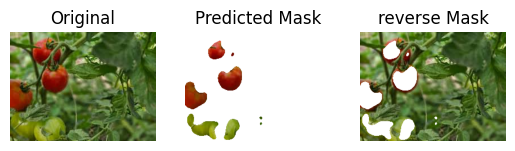

In [ ]:
image_path = "images.jpg"
pred_class, prob, masked_img, img_rgb, img_leaf_only = predict_image(image_path, seg_model, classifier_model, device)

print(f"Predicted: {pred_class} ({prob*100:.2f}%)")

plt.subplot(1,3,1)
plt.imshow(img_rgb)
plt.title("Original")
plt.axis("off")

plt.subplot(1,3,2)
plt.imshow(masked_img, cmap="gray")
plt.title("Predicted Mask")
plt.axis("off")

plt.subplot(1,3,3)
plt.imshow(img_leaf_only)
plt.title("reverse Mask")
plt.axis("off")
plt.show()

In [ ]:
DISEASE_CLASSES = load_disease_classes("class_names.json")

candidate_diseases = filter_diseases_by_crop(pred_class, DISEASE_CLASSES)

print("Allowed disease classes for this crop:")
for d in candidate_diseases:
    print("-", d)

Allowed disease classes for this crop:
- Tomato___Late_blight
- Tomato___healthy
- Tomato___Early_blight
- Tomato___Septoria_leaf_spot
- Tomato___Tomato_Yellow_Leaf_Curl_Virus
- Tomato___Bacterial_spot
- Tomato___Target_Spot
- Tomato___Tomato_mosaic_virus
- Tomato___Leaf_Mold
- Tomato___Spider_mites Two-spotted_spider_mite


In [ ]:
result = predict_with_crop_filter(img_leaf_only, candidate_diseases)
print(result)

{'disease': 'Tomato___Tomato_mosaic_virus', 'confidence': 0.9171885251998901, 'candidate_probs': [0.022851668298244476, 0.0015625501982867718, 0.021128876134753227, 0.0018712248420342803, 0.0034825678449124098, 8.608708981228119e-07, 0.00011329918925184757, 0.9171885251998901, 0.02631179243326187, 0.0054886857978999615]}
